# TP 2 : Branch-and-bound applied to a knapsack problem

### Initialisation (à faire une seule fois)

In [4]:
DISPLAY_TREE = true
if DISPLAY_TREE
    # Les 2 lignes suivantes à décommenter sur les machines persos
    # import Pkg; 
    # Pkg.add("GraphRecipes"); Pkg.add("Plots"); 
    using GraphRecipes, Plots #only used to visualize the search tree at the end of the branch-and-bound
end

yes


### Récupération des données

In [5]:
function readKnaptxtInstance(filename)
    price=Int64[]
    weight=Int64[]
    KnapCap=Int64[]
    open(filename) do f
        for i in 1:3
            tok = split(readline(f))
            if(tok[1] == "ListPrices=")
                for i in 2:(length(tok)-1)
                    push!(price,parse(Int64, tok[i]))
                end
            elseif(tok[1] == "ListWeights=")
                for i in 2:(length(tok)-1)
                    push!(weight,parse(Int64, tok[i]))
                end
            elseif(tok[1] == "Capacity=")
                push!(KnapCap, parse(Int64, tok[2]))
            else
                println("Unknown read :", tok)
            end
        end
    end
    capacity=KnapCap[1]
    return price, weight, capacity
end

readKnaptxtInstance (generic function with 1 method)

### Tests de sondabilités TA, TO et TR basés sur le modèle linéaire

In [6]:
function testSondability_LP(model2, x, BestProfit, Bestsol)
    TA, TO, TR = false, false, false
    if(termination_status(model2) == MOI.INFEASIBLE)#Test de faisabilite
        TA=true
        println("TA")
    elseif(objective_value(model2) <= BestProfit) #Test d'optimalite
        TO=true
        println("TO")
    elseif( prod(abs.([round.(v, digits=0) for v in value.(x)]-value.(x)) .<= fill(10^-5, size(x)))
        ) #Test de resolution
        TR=true
        println("TR")
        #if (value(benef) >= BestProfit)
        if (objective_value(model2) >= BestProfit)
            Bestsol = value.(x)
            #BestProfit=value(benef)
            BestProfit=objective_value(model2)
            println("\nNew Solution memorized ", Bestsol, " with bestprofit ", BestProfit, "\n")
        end
    else
        println("non sondable")
    end
    TA, TO, TR, Bestsol, BestProfit
end

testSondability_LP (generic function with 1 method)

## Procédure de séparation (branching) et stratégie d'exploration permettant de se placer au prochain noeud à traiter

In [7]:
function separateNodeThenchooseNext_lexicographic_depthfirst!(listobjs, listvals, n)
    # this node is non-sondable. Apply the branching criterion to separate it into two subnodes
    # and choose the child-node at the left

    # lexicographic branching criterion: branch on the 1st object not yet fixed
    i, obj = 1, 0
    while((i <= n) && (obj==0))
        if(!(i in listobjs))
            obj=i
        end
        i+=1
    end

    println("\nbranch on object ", obj, "\n")

    # depthfirst exploration strategy: the node selected will be the most left of the child-nodes just created
    push!(listobjs,obj) #save the identity of the object selected for branching
    push!(listvals,1.0) #save the node selected, identified by the value assigned to the variable/object chosen
end


function exploreNextNode_depthfirst!(listobjs, listvals, listnodes)
    #this node is sondable, go back to parent node then right child if possible

    stop=false
    #check if we are not at the root node
    if (length(listobjs)>= 1)
        #go back to parent node
        obj=pop!(listobjs)
        theval=pop!(listvals)
        tmp=pop!(listnodes)

        #go to right child if possible, otherwise go back to parent
        while( (theval==0.0) && (length(listobjs)>= 1))
            obj=pop!(listobjs)
            theval=pop!(listvals)
            tmp=pop!(listnodes)
        end
        if theval==1.0
            push!(listobjs,obj)
            push!(listvals,0.0)
        else
            println("\nFINISHED")
            stop=true
        end
    else
        #the root node was sondable
        println("\nFINISHED")
        stop=true
    end
    return stop
end

exploreNextNode_depthfirst! (generic function with 1 method)

###  Création de la relaxation linéaire (= modèle associé au noeud 0): <span style="color:red"> SECTION A SUPPRIMER !!!! </span>

<span style="color:red"> Cette section est à commenter/supprimer et remplacer par vos propres calculs de bornes supérieures et autres, par exemple basées sur les bornes 1 et 2 vues en cours, ou d'autres calculs de bornes de votre choix/conception validés au préalable par votre encadrant/e de TP </span>

In [8]:
# Les 3 lignes suivantes à décommenter sur les machines persos
# import Pkg; 
# Pkg.add("Clp");
# Pkg.add("JuMP");
using JuMP, Clp #to comment for the lab class

function updateModele_LP!(model2, x, listobjs, listvals)
    for i in 1:length(listobjs)
        set_lower_bound(x[listobjs[i]],listvals[i])
        set_upper_bound(x[listobjs[i]],listvals[i])
    end
end

function reset_LP!(model2, x, listobjs)
    for i in 1:length(listobjs)
        set_lower_bound(x[listobjs[i]],0.0)
        set_upper_bound(x[listobjs[i]],1.0)
    end
end

function resetAll_LP!(model2, x)
    for i in 1:length(x)
        set_lower_bound(x[i],0.0)
        set_upper_bound(x[i],1.0)
    end
end

function createModel_LP(price, weight, capacity)
# ROOT NODE

    n=length(price)

    model2 = Model(Clp.Optimizer) # set optimizer
    set_optimizer_attribute(model2, "LogLevel", 0) #don't display anything during solve
    set_optimizer_attribute(model2, "Algorithm", 4) #LP solver chosen is simplex

    # define x variables as CONTINUOUS (recall that it is not possible to define binary variables in Clp)
    @variable(model2, 0 <= x[i in 1:n] <= 1)

    # define objective function
    @objective(model2, Max, sum(price[i]*x[i] for i in 1:n))

    # define the capacity constraint
    @constraint(model2, sum(weight[i]*x[i] for i in 1:n) <=  capacity)

    println(model2)

    return model2, x
end

createModel_LP (generic function with 1 method)

### Boucle principale : résoudre une relaxation, appliquer les tests de sondabilité, identifier le prochain noeud, répéter.

In [13]:
function solveKnapInstance(filename)

    price, weight, capacity = readKnaptxtInstance(filename)

    model2, x = createModel_LP(price, weight, capacity)
    
    #create the structure to memorize the search tree for visualization at the end
    trParentnodes=Int64[] #will store orig node of arc in search tree
    trChildnodes=Int64[] #will store destination node of arc in search tree
    trNamenodes=[] #will store names of nodes in search tree
    
    #intermediate structure to navigate in the search tree
    listobjs=Int64[]
    listvals=Float64[]
    listnodes=Int64[]

    BestProfit::Float64=-1.0
    Bestsol=Float64[]

    current_node_number::Int64=0
    stop = false

    while(!stop)

        println("\nNode number ", current_node_number, ": \n---------------\n")

        if DISPLAY_TREE
        #Update the graphical tree
            push!(trNamenodes,current_node_number+1) 
            if(length(trNamenodes)>=2)
                push!(trParentnodes,listnodes[end]+1) # +1 because the 1st node is "node 0"
                push!(trChildnodes, current_node_number+1) # +1 because the 1st node is "node 0"
            end
        end
        
        push!(listnodes, current_node_number)
        
        #create LP of current node
        updateModele_LP!(model2, x, listobjs, listvals)
        
        println("----------------------------------------------------------")
        println(model2)
        
        print("Solve the LP model of the current node to compute its bound: start ... ")

        status = optimize!(model2)

        println("... end"); 

        print(": Solution LP")
        if(termination_status(model2) == MOI.INFEASIBLE)#(has_values(model2))
            print(" : NOT AVAILABLE (probably infeasible or ressources limit reached)")
        else
            print(" ", objective_value(model2))
            [print("\t", name(v),"=",value(v)) for v in all_variables(model2)] 
        end
        println(" "); 


        println("\nPrevious Solution memorized ", Bestsol, " with bestprofit ", BestProfit, "\n")

        TA, TO, TR, Bestsol, BestProfit = testSondability_LP(model2, x, BestProfit, Bestsol)

        is_node_sondable = TA || TO || TR

        #Reset_LP!(model2, x, listobjs)

        if(!is_node_sondable)
            separateNodeThenchooseNext_lexicographic_depthfirst!(listobjs, listvals, length(price))
        else
            stop = exploreNextNode_depthfirst!(listobjs, listvals, listnodes)
        end
        
        resetAll_LP!(model2, x)

        current_node_number = current_node_number + 1
    end

    println("\n******\n\nOptimal value = ", BestProfit, "\n\nOptimal x=", Bestsol)

    return BestProfit, Bestsol, trParentnodes, trChildnodes, trNamenodes

end


solveKnapInstance (generic function with 1 method)

### Affichage du résultat final

In [14]:
function solveNdisplayKnap(filename)

    println("\n Branch-and-Bound for solving a knapsack problem. \n\n Solving instance '" * filename * "'\n")

    BestProfit, Bestsol, trParentnodes, trChildnodes, trNamenodes = solveKnapInstance(filename)

    println("\n******\n\nOptimal value = ", BestProfit, "\n\nOptimal x=", Bestsol)
    if DISPLAY_TREE
        println("\n Branch-and-bound tree visualization : start display ...")
        display(graphplot(trParentnodes, trChildnodes, names=trNamenodes, method=:tree))
        println("... end display. \n\n")
    end
end

solveNdisplayKnap (generic function with 1 method)


 Branch-and-Bound for solving a knapsack problem. 

 Solving instance 'InstancesKnapSack/test.opb.txt'

Max 42 x[1] + 40 x[2] + 12 x[3] + 25 x[4]
Subject to
 7 x[1] + 4 x[2] + 3 x[3] + 5 x[4] ≤ 10.0
 x[1] ≥ 0.0
 x[2] ≥ 0.0
 x[3] ≥ 0.0
 x[4] ≥ 0.0
 x[1] ≤ 1.0
 x[2] ≤ 1.0
 x[3] ≤ 1.0
 x[4] ≤ 1.0


Node number 0: 
---------------

----------------------------------------------------------
Max 42 x[1] + 40 x[2] + 12 x[3] + 25 x[4]
Subject to
 7 x[1] + 4 x[2] + 3 x[3] + 5 x[4] ≤ 10.0
 x[1] ≥ 0.0
 x[2] ≥ 0.0
 x[3] ≥ 0.0
 x[4] ≥ 0.0
 x[1] ≤ 1.0
 x[2] ≤ 1.0
 x[3] ≤ 1.0
 x[4] ≤ 1.0

Solve the LP model of the current node to compute its bound: start ... ... end
: Solution LP 76.0	x[1]=0.857142857142857	x[2]=1.0	x[3]=0.0	x[4]=0.0 

Previous Solution memorized Float64[] with bestprofit -1.0

non sondable

branch on object 1


Node number 1: 
---------------

----------------------------------------------------------
Max 42 x[1] + 40 x[2] + 12 x[3] + 25 x[4]
Subject to
 7 x[1] + 4 x[2] + 3 x[3] + 

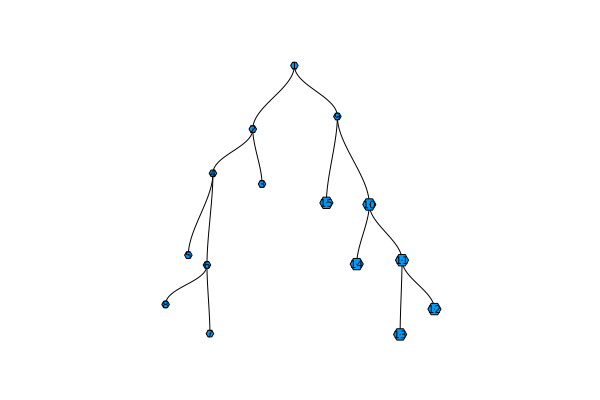

... end display. 




In [15]:
INSTANCE = "InstancesKnapSack/test.opb.txt"

solveNdisplayKnap(INSTANCE)

# Rendu

## Questions préliminiaires
- **Question 1:**
On parcours les objet dans l'ordre de la liste dans laquelle on les a stockées
- **Question 2:**
((Solver Jump)) qui calcul le maximum avec relaxation linéaire
- **Question 3:**
TA: Avec l'objet on a une capacité restante dans le sac strictement négative
TO: La borne superieur est inferieur ou égale à la meilleur valeur déjà atteinte.
TR: la borne superieur est atteinte avec un nombre entier d'objet (si meilleur que valeur précedente on la retient pour TO).
- **Question 4:**
Exploration en profondeur.

## Code et analyse

In [16]:
# x: liste (min,max) selon l'état du sac à dos
# n: nb d'objets déjà fixés
# p,w,c: prix, poids, capacité
# return: le prix max selon la borne1
function bound1(x, n, p, w, C)
    used_C = 0
    current_price = 0
    for i in 1 : n
        # de 1 à n, min = max (valeur fixée)
        used_C += x[i][1] * w[i]
        current_price += x[i][1] * p[i]
    end
    
    best_ratio = max(p / w)
    best_price = (C - used_C) * best_ratio + current_price
    
    best_price
end

borne1 (generic function with 1 method)

In [ ]:
function testSondability(x, listobjs, listvals, BestProfit, BestSol)
    TA, TO, TR = false, false, false
    used_capacity = sum(weight[i]*x[i] for i in 1:n)
end

In [22]:
function updateModel(x, listobjs, listvals)
    for i in : length(listobjs)
        x[listobjs[i]][1] = listvals[i]
        x[listobjs[i]][2] = listvals[i]
    end
    x
end

function resetAll(x)
    for i in 1 : length(x)
        x[i][1] = 0.0
        x[i][2] = 1.0
    end
    x
end

function createModel(price, weight, capacity)
    x = Float64[length(price)][2]
    x = resetAll(x)
end

createModel (generic function with 1 method)

In [24]:
function solve(filename)
    
    price, weight, capacity = readKnaptxtInstance(filename)
    
    x = createModel(price, weight, capacity)
    
    #create the structure to memorize the search tree for visualization at the end
    trParentnodes=Int64[] #will store orig node of arc in search tree
    trChildnodes=Int64[] #will store destination node of arc in search tree
    trNamenodes=[] #will store names of nodes in search tree
    
    #intermediate structure to navigate in the search tree
    listobjs=Int64[]
    listvals=Float64[]
    listnodes=Int64[]
    
    BestProfit::Float64=-1.0
    Bestsol=Float64[]
    
    current_node_number::Int64=0
    stop = false
    
    while (!stop)
        println("\nNode number ", current_node_number, ": \n---------------\n")

        if DISPLAY_TREE
        #Update the graphical tree
            push!(trNamenodes,current_node_number+1) 
            if(length(trNamenodes)>=2)
                push!(trParentnodes,listnodes[end]+1) # +1 because the 1st node is "node 0"
                push!(trChildnodes, current_node_number+1) # +1 because the 1st node is "node 0"
            end
        end
        
        push!(listnodes, current_node_number)
        
        x = updateModel(x, listobjs, listvals)
        
        println("----------------------------------------------------------")
        println("modèle actuel:")
        println(x)
        
        TA, TO, TR, BestSol, BestProfit = testSondability(x, listobjs, listvals, BestProfit, BestSol)
        
    end
end

solve (generic function with 1 method)